# 비모수적 개별 처치 효과(CATE) 추정

- 목표: 두 개의 다른 데이터셋(아이스크림, 이메일)을 사용하여, CATE(개별 처치 효과) 추정 시 선형 모델(OLS)의 한계와 비모수적 메타-러너(S/T/X-Learner)의 우수성을 비교 검증합니다.
- 데이터 1 (연속형 T):
    - 학습: ice_cream_sales.csv (편향된 관측 데이터)
    - 평가: ice_cream_sales_rnd.csv (무작위 RCT 데이터)
- 데이터 2 (이진형 T):
    - 학습: invest_email_biased.csv (편향된 관측 데이터)
    - 평가: invest_email_rnd.csv (무작위 RCT 데이터)
- 평가 지표:
    - 수치: AUUC (Area Under Uplift Curve) - 높을수록 우수함.
    - 시각화: 누적 성과 곡선 (Cumulative Gain Plot) - 베이스라인(무작위)보다 높아야 함.

## 1. 라이브러리 및 헬퍼 함수

In [62]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.base import clone
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Callable

# 시각화 스타일 설정
plt.style.use('ggplot')
sns.set_palette('colorblind')

In [63]:
# --- 헬퍼 함수 (연속형 처치용) ---
def sensitivity(data, y, t):
    """
    (연속형 T용) 단일 변수 선형 회귀의 기울기(민감도)를 계산합니다.
    """
    return (np.sum((data[t] - data[t].mean()) * (data[y] - data[y].mean())) /
            np.sum((data[t] - data[t].mean())**2))

def cumulative_gain_continuous(dataset, prediction, y, t, min_periods=30, steps=100):
    """
    (연속형 T용) 누적 성과 곡선(Cumulative Gain)을 계산합니다.
   
    """
    size = dataset.shape[0]
    ordered_df = dataset.sort_values(prediction, ascending=False).reset_index(drop=True)
    n_rows = list(range(min_periods, size, size // steps)) + [size]
    
    # (rows/size)로 정규화합니다.
    return np.array([sensitivity(ordered_df.head(rows), y, t) * (rows / size) for rows in n_rows])

def auuc_score_continuous(data, cate, y, t, min_periods=30, steps=100):
    """(연속형 T용) AUUC 점수를 계산합니다."""
    model_gain = cumulative_gain_continuous(data, cate, y, t, min_periods, steps)
    
    # 베이스라인 (전체 데이터의 평균 민감도 * 비율)
    baseline_sens = sensitivity(data, y, t)
    baseline_gain = np.linspace(0, 1, len(model_gain)) * baseline_sens * (len(data) / (len(data) - min_periods + 1)) # 스케일 조정
    
    # 모델 성과 - 베이스라인 성과의 면적
    auuc = (model_gain - baseline_gain).sum() / len(model_gain)
    return auuc

In [64]:
# --- 헬퍼 함수 (이진형 처치용) ---

def elast(data, y, t):
    """(이진형 T용) ATE(평균 효과)를 계산합니다."""
    ate = (data.query(f"{t}==1")[y].mean() -
           data.query(f"{t}==0")[y].mean())
    return ate

def cumulative_gain_binary(data, cate, y, t, min_rows=30, steps=100):
    """(이진형 T용) 누적 성과 곡선(Uplift Curve)을 계산합니다."""
    data = data.copy()
    data["cate"] = data[cate]
    data = data.sort_values("cate", ascending=False)
    
    thresholds = np.linspace(0, 100, steps + 1)[1:]
    
    gains = []
    for threshold in thresholds:
        n_rows = int(len(data) * (threshold / 100))
        if n_rows < min_rows:
            continue
        
        quant_data = data.head(n_rows)
        gain = elast(quant_data, y, t)
        gains.append(gain)
        
    return np.array(gains)

def auuc_score_binary(data, cate, y, t, min_rows=30, steps=100):
    """(이진형 T용) AUUC 점수를 계산합니다."""
    model_gain = cumulative_gain_binary(data, cate, y, t, min_rows, steps)
    baseline_ate = elast(data, y, t)
    
    auuc = (model_gain - baseline_ate).sum() / len(model_gain)
    return auuc

## 2. Part A: 아이스크림 데이터 (연속형 T)
먼저 ice_cream_sales.csv(편향된 학습용)로 모델들을 학습시키고, ice_cream_sales_rnd.csv(무작위 평가용)로 CATE 추정 성능을 비교합니다.

In [65]:
train_ice = pd.read_csv("ice_cream_sales.csv")
test_ice = pd.read_csv("ice_cream_sales_rnd.csv")

In [66]:
# 타입 변환
train_ice['weekday'] = train_ice['weekday'].astype('category')
test_ice['weekday'] = test_ice['weekday'].astype('category')

# 변수 정의
Y_ice = "sales"
T_ice_cont = "price"      # S-Learner, OLS용 연속형 처치
T_ice_binary = "price_binary" # T/X-Learner, 평가용 이진 처치
X_ice = ["temp", "weekday", "cost"]

# T/X-Learner 및 공정한 AUUC 평가를 위해 price를 이진화
price_median_train = train_ice[T_ice_cont].median()
train_ice[T_ice_binary] = (train_ice[T_ice_cont] > price_median_train).astype(int)
test_ice[T_ice_binary] = (test_ice[T_ice_cont] > price_median_train).astype(int)

# 테스트 데이터 예측값 저장용
test_preds_ice = test_ice.copy()

# 학습/테스트 데이터 정의
X_train_ice, Y_train_ice = train_ice[X_ice], train_ice[Y_ice]
T_train_ice_cont, T_train_ice_binary = train_ice[T_ice_cont], train_ice[T_ice_binary]
X_test_ice = test_ice[X_ice]

In [67]:
# --- 모델 1: 선형 CATE (OLS) ---
formula_linear_ice = 'sales ~ price * (temp + C(weekday) + cost)'
linear_model_ice = smf.ols(formula_linear_ice, data=train_ice).fit()

# CATE 추정 함수 (연속형 T용)
def get_linear_cate_predictions(model, df, t_col):
    df_t1 = df.copy(); df_t1[t_col] = df_t1[t_col] + 1
    return model.predict(df_t1) - model.predict(df)

test_preds_ice['cate_linear'] = get_linear_cate_predictions(linear_model_ice, test_preds_ice, T_ice_cont)


# --- 모델 2: S-Learner (RF) ---
rf_model_base = RandomForestRegressor(n_estimators=100, min_samples_leaf=20, random_state=42)
s_learner_ice = clone(rf_model_base)
s_learner_ice.fit(train_ice[X_ice + [T_ice_cont]], Y_train_ice)

# CATE 추정
X_test_s_ice_t1 = X_test_ice.copy(); X_test_s_ice_t1[T_ice_cont] = test_ice[T_ice_cont] + 1
X_test_s_ice_t0 = X_test_ice.copy(); X_test_s_ice_t0[T_ice_cont] = test_ice[T_ice_cont]
test_preds_ice['cate_s_learner'] = s_learner_ice.predict(X_test_s_ice_t1) - s_learner_ice.predict(X_test_s_ice_t0)


# --- 모델 3: T-Learner (RF) ---
# (이진형 T_ice_binary 사용)
t1_learner_ice = clone(rf_model_base)
t1_learner_ice.fit(X_train_ice[T_train_ice_binary == 1], Y_train_ice[T_train_ice_binary == 1])
t0_learner_ice = clone(rf_model_base)
t0_learner_ice.fit(X_train_ice[T_train_ice_binary == 0], Y_train_ice[T_train_ice_binary == 0])
test_preds_ice['cate_t_learner'] = t1_learner_ice.predict(X_test_ice) - t0_learner_ice.predict(X_test_ice)


# --- 모델 4: X-Learner (RF) ---
# (이진형 T_ice_binary 사용)
D_t1 = Y_train_ice[T_train_ice_binary == 1] - t0_learner_ice.predict(X_train_ice[T_train_ice_binary == 1])
D_t0 = t1_learner_ice.predict(X_train_ice[T_train_ice_binary == 0]) - Y_train_ice[T_train_ice_binary == 0]

x1_learner_ice = clone(rf_model_base); x1_learner_ice.fit(X_train_ice[T_train_ice_binary == 1], D_t1)
x0_learner_ice = clone(rf_model_base); x0_learner_ice.fit(X_train_ice[T_train_ice_binary == 0], D_t0)

prop_model_ice = LogisticRegression(random_state=42, solver='lbfgs', max_iter=1000)
prop_model_ice.fit(X_train_ice, T_train_ice_binary)
prop_scores_ice = prop_model_ice.predict_proba(X_test_ice)[:, 1]

test_preds_ice['cate_x_learner'] = (prop_scores_ice * x0_learner_ice.predict(X_test_ice)) + \
                                   ((1 - prop_scores_ice) * x1_learner_ice.predict(X_test_ice))

test_ice(무작위 데이터셋)를 기준으로 아이스크림 예제의 모델들(선형 vs. 메타)을 비교합니다.
참고: AUUC 평가는 T/X-Learner와 공정한 비교를 위해 이진화된 처치(T_ice_binary)를 기준으로 수행합니다.

--- 아이스크림 데이터 AUUC 점수  ---
                AUUC Score (IceCream)
X-Learner (RF)              12.497704
T-Learner (RF)              12.323083
Linear (OLS)                 6.769121
S-Learner (RF)               0.841975


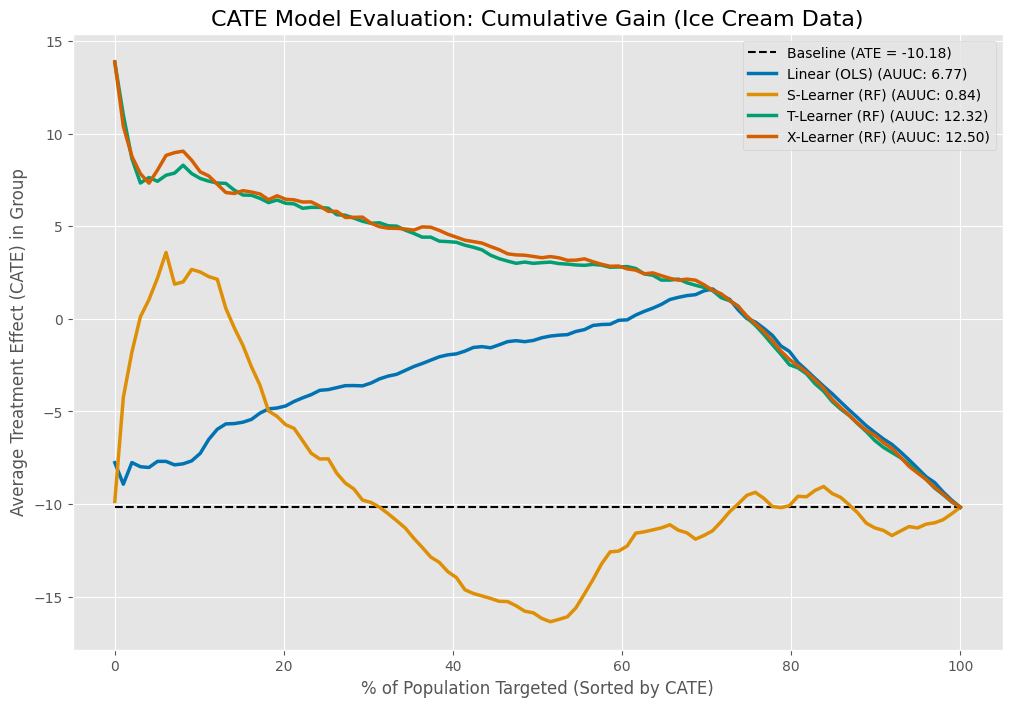

In [68]:
# ---  수치 비교 (AUUC) ---
models_ice = {
    'Linear (OLS)': 'cate_linear',
    'S-Learner (RF)': 'cate_s_learner',
    'T-Learner (RF)': 'cate_t_learner',
    'X-Learner (RF)': 'cate_x_learner'
}
auuc_results_ice = {}

for name, col in models_ice.items():
    auuc = auuc_score_binary(test_preds_ice, col, Y_ice, T_ice_binary)
    auuc_results_ice[name] = auuc

auuc_df_ice = pd.DataFrame.from_dict(auuc_results_ice, orient='index', columns=['AUUC Score (IceCream)'])
print("--- 아이스크림 데이터 AUUC 점수  ---")
print(auuc_df_ice.sort_values('AUUC Score (IceCream)', ascending=False))


# ---  시각화 (Cumulative Gain Plot) ---
plt.figure(figsize=(12, 8))

baseline_ate_ice = elast(test_preds_ice, Y_ice, T_ice_binary)
plt.plot([0, 100], [baseline_ate_ice, baseline_ate_ice], 'k--', 
         label=f'Baseline (ATE = {baseline_ate_ice:.2f})')

for name, col in models_ice.items():
    gain = cumulative_gain_binary(test_preds_ice, col, Y_ice, T_ice_binary)
    plt.plot(np.linspace(0, 100, len(gain)), gain, 
             label=f'{name} (AUUC: {auuc_results_ice[name]:.2f})', 
             linewidth=2.5)

plt.title('CATE Model Evaluation: Cumulative Gain (Ice Cream Data)', fontsize=16)
plt.xlabel('% of Population Targeted (Sorted by CATE)')
plt.ylabel('Average Treatment Effect (CATE) in Group')
plt.legend()
plt.show()

## 3. Part B: 이메일 마케팅 데이터 (이진형 T)
모든 모델은 편향된 train_email 데이터로 학습하고, 무작위 test_email 데이터로 평가합니다.

In [69]:
# --- 데이터 로드 및 변수 정의 ---
train_email = pd.read_csv("invest_email_biased.csv")
test_email = pd.read_csv("invest_email_rnd.csv")

Y_email = "converted"
T_email = "em1"
X_email = ["age", "income", "insurance", "invested"]

# 테스트 데이터 예측값 저장용
test_preds_email = test_email.copy()

# 학습/테스트 데이터 정의
X_train_em, Y_train_em = train_email[X_email], train_email[Y_email]
T_train_em = train_email[T_email]
X_test_em = test_email[X_email]

In [ ]:
# --- 모델 1: 선형 CATE (OLS) ---
formula_linear_email = 'converted ~ em1 * (age + income + insurance + invested)'
linear_model_email = smf.ols(formula_linear_email, data=train_email).fit()

# CATE 추정
df_t1 = X_test_em.copy(); df_t1[T_email] = 1
df_t0 = X_test_em.copy(); df_t0[T_email] = 0
test_preds_email['cate_linear'] = linear_model_email.predict(df_t1) - linear_model_email.predict(df_t0)


# --- 모델 2: S-Learner (RF) ---
rf_model_email = RandomForestRegressor(n_estimators=100, min_samples_leaf=30, max_depth=3, random_state=42)
s_learner_email = clone(rf_model_email)
s_learner_email.fit(train_email[X_email + [T_email]], Y_train_em)

# CATE 추정
X_test_s_t1_em = X_test_em.copy(); X_test_s_t1_em[T_email] = 1
X_test_s_t0_em = X_test_em.copy(); X_test_s_t0_em[T_email] = 0
test_preds_email['cate_s_learner'] = s_learner_email.predict(X_test_s_t1_em) - s_learner_email.predict(X_test_s_t0_em)


# --- 모델 3: T-Learner (RF) ---
t1_learner_email = clone(rf_model_email)
t1_learner_email.fit(X_train_em[T_train_em == 1], Y_train_em[T_train_em == 1])
t0_learner_email = clone(rf_model_email)
t0_learner_email.fit(X_train_em[T_train_em == 0], Y_train_em[T_train_em == 0])
test_preds_email['cate_t_learner'] = t1_learner_email.predict(X_test_em) - t0_learner_email.predict(X_test_em)


# --- 모델 4: X-Learner (RF) ---
D_t1_em = Y_train_em[T_train_em == 1] - t0_learner_email.predict(X_train_em[T_train_em == 1])
D_t0_em = t1_learner_email.predict(X_train_em[T_train_em == 0]) - Y_train_em[T_train_em == 0]

x1_learner_email = clone(rf_model_email)
x1_learner_email.fit(X_train_em[T_train_em == 1], D_t1_em)
x0_learner_email = clone(rf_model_email)
x0_learner_email.fit(X_train_em[T_train_em == 0], D_t0_em)

# 성향 점수 모델 
prop_model_email = LogisticRegression(random_state=42, solver='lbfgs', penalty=None, max_iter=1000)
prop_model_email.fit(X_train_em, T_train_em)

# CATE 추정
prop_scores_em = prop_model_email.predict_proba(X_test_em)[:, 1]
test_preds_email['cate_x_learner'] = (prop_scores_em * x0_learner_email.predict(X_test_em)) + \
                                     ((1 - prop_scores_em) * x1_learner_email.predict(X_test_em))

test_email(무작위 데이터셋)를 기준으로 **이메일 예제의 모델들(선형 vs. 메타)**을 비교합니다.

--- 이메일 데이터 AUUC 점수 (편향된 데이터로 학습) ---
                AUUC Score (Email)
X-Learner (RF)            0.038409
Linear (OLS)              0.033553
T-Learner (RF)            0.030136
S-Learner (RF)           -0.011199


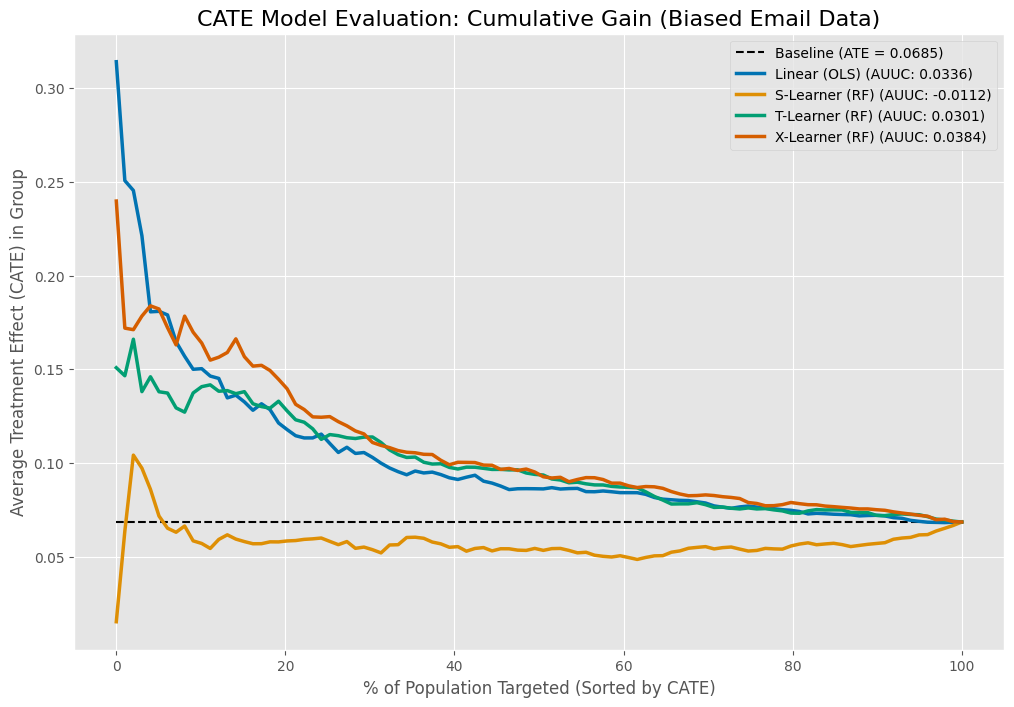

In [77]:
# --- 수치 비교 (AUUC) ---
models_email = {
    'Linear (OLS)': 'cate_linear',
    'S-Learner (RF)': 'cate_s_learner',
    'T-Learner (RF)': 'cate_t_learner',
    'X-Learner (RF)': 'cate_x_learner'
}
auuc_results_email = {}

for name, col in models_email.items():
    auuc = auuc_score_binary(test_preds_email, col, Y_email, T_email)
    auuc_results_email[name] = auuc

auuc_df_email = pd.DataFrame.from_dict(auuc_results_email, orient='index', columns=['AUUC Score (Email)'])
print("--- 이메일 데이터 AUUC 점수 (편향된 데이터로 학습) ---")
print(auuc_df_email.sort_values('AUUC Score (Email)', ascending=False))


# --- 시각화 (Cumulative Gain Plot) ---
plt.figure(figsize=(12, 8))

baseline_ate_email = elast(test_preds_email, Y_email, T_email)
plt.plot([0, 100], [baseline_ate_email, baseline_ate_email], 'k--', 
         label=f'Baseline (ATE = {baseline_ate_email:.4f})')

for name, col in models_email.items():
    gain = cumulative_gain_binary(test_preds_email, col, Y_email, T_email)
    plt.plot(np.linspace(0, 100, len(gain)), gain, 
             label=f'{name} (AUUC: {auuc_results_email[name]:.4f})', 
             linewidth=2.5)

plt.title('CATE Model Evaluation: Cumulative Gain (Biased Email Data)', fontsize=16)
plt.xlabel('% of Population Targeted (Sorted by CATE)')
plt.ylabel('Average Treatment Effect (CATE) in Group')
plt.legend()
plt.show()

### 질문이나 의견을 남겨주세요.
<script src="https://utteranc.es/client.js"
        repo="CausalInferenceLab/awesome-causal-inference-python"
        issue-term="pathname"
        theme="github-light"
        crossorigin="anonymous"
        async>
</script>